In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    roc_auc_score, average_precision_score, RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

In [3]:
TRAIN_PATH = r"C:\Users\aditi\Downloads\archive (1)\fraudTrain.csv"
TEST_PATH = r"C:\Users\aditi\Downloads\archive (1)\fraudTest.csv"

def make_synthetic_fraud_data(n=5000, fraud_rate=0.03, seed=0):
    """Generates a toy dataset matching the fraudTrain/fraudTest schema,
    used only as a fallback so the notebook is runnable without the real files."""
    rng = np.random.default_rng(seed)
    start = pd.Timestamp('2023-01-01')
    trans_dates = start + pd.to_timedelta(rng.integers(0, 365 * 24 * 3600, n), unit='s')
    dobs = pd.Timestamp('1990-01-01') - pd.to_timedelta(rng.integers(0, 60 * 365 * 24 * 3600, n), unit='s')
    lat = rng.uniform(25, 49, n)
    long = rng.uniform(-124, -67, n)
    amt = np.round(rng.exponential(60, n), 2)
    is_fraud = (rng.random(n) < fraud_rate).astype(int)
    amt[is_fraud == 1] *= rng.uniform(3, 8, is_fraud.sum())
    return pd.DataFrame({
        'Unnamed: 0': np.arange(n),
        'trans_date_trans_time': trans_dates,
        'cc_num': rng.integers(10**11, 10**12, n),
        'merchant': rng.choice([f'merchant_{i}' for i in range(50)], n),
        'category': rng.choice(['grocery_pos', 'shopping_net', 'gas_transport', 'misc_net', 'entertainment'], n),
        'amt': amt,
        'first': 'John', 'last': 'Doe',
        'gender': rng.choice(['M', 'F'], n),
        'street': '123 Main St',
        'city': rng.choice(['Springfield', 'Riverside', 'Fairview'], n),
        'state': rng.choice(['CA', 'NY', 'TX'], n),
        'zip': rng.integers(10000, 99999, n),
        'lat': lat, 'long': long,
        'city_pop': rng.integers(500, 500000, n),
        'job': 'Engineer',
        'dob': dobs,
        'trans_num': [f't{i}' for i in range(n)],
        'unix_time': trans_dates.astype('int64') // 10**9,
        'merch_lat': lat + rng.normal(0, 0.5, n),
        'merch_long': long + rng.normal(0, 0.5, n),
        'is_fraud': is_fraud
    })

try:
    df_train = pd.read_csv(TRAIN_PATH, header=0)
    df_test = pd.read_csv(TEST_PATH, header=0)
    print('Loaded real data from disk.')
except FileNotFoundError:
    print(f'Could not find {TRAIN_PATH} / {TEST_PATH} - using synthetic demo data instead.')
    df_train = make_synthetic_fraud_data(n=8000, seed=1)
    df_test = make_synthetic_fraud_data(n=2000, seed=2)

Loaded real data from disk.


In [4]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
df_train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [7]:
print('Train shape:', df_train.shape)
print('Test shape:', df_test.shape)
print('Missing values in train:', df_train.isnull().sum().sum())
print('Missing values in test:', df_test.isnull().sum().sum())
print('Duplicate rows in train:', df_train.duplicated().sum())

Train shape: (1296675, 23)
Test shape: (555719, 23)
Missing values in train: 0
Missing values in test: 0
Duplicate rows in train: 0


is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64


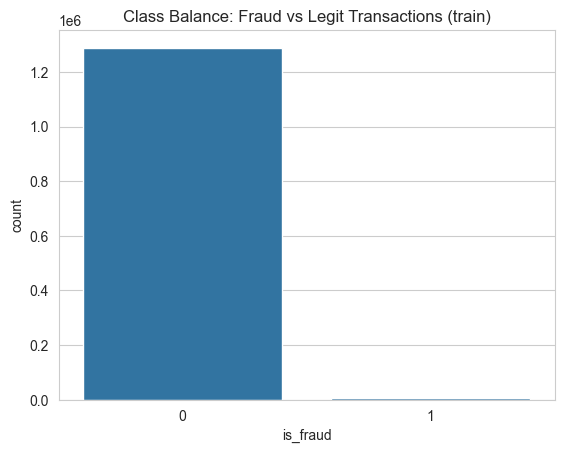

In [8]:
fraud_rate = df_train['is_fraud'].value_counts(normalize=True)
print(fraud_rate)
sns.countplot(x='is_fraud', data=df_train)
plt.title('Class Balance: Fraud vs Legit Transactions (train)')
plt.show()

In [9]:
df_combined = pd.concat([df_train, df_test], axis=0, ignore_index=True)
unnamed_cols = [c for c in df_combined.columns if c.startswith('Unnamed')]
df_combined.drop(columns=unnamed_cols, inplace=True)
df_combined.shape

(1852394, 22)

In [10]:
df_combined['trans_date_trans_time'] = pd.to_datetime(df_combined['trans_date_trans_time'])
df_combined['dob'] = pd.to_datetime(df_combined['dob'])

df_combined['trans_hour'] = df_combined['trans_date_trans_time'].dt.hour
df_combined['trans_day_of_week'] = df_combined['trans_date_trans_time'].dt.dayofweek
df_combined['trans_month'] = df_combined['trans_date_trans_time'].dt.month
df_combined['age'] = ((df_combined['trans_date_trans_time'] - df_combined['dob']).dt.days // 365).astype(int)

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between two lat/long points, in kilometers."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

df_combined['distance_km'] = haversine_km(
    df_combined['lat'], df_combined['long'],
    df_combined['merch_lat'], df_combined['merch_long']
)

drop_cols = ['first', 'last', 'job', 'dob', 'trans_num', 'street',
             'trans_date_trans_time', 'city', 'state', 'zip', 'cc_num']
df_combined.drop(columns=[c for c in drop_cols if c in df_combined.columns], inplace=True)
df_combined.head()

,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_month,age,distance_km
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,30,78.597568
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,40,30.212176
2,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,56,108.206083
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,52,95.673231
4,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,32,77.556744


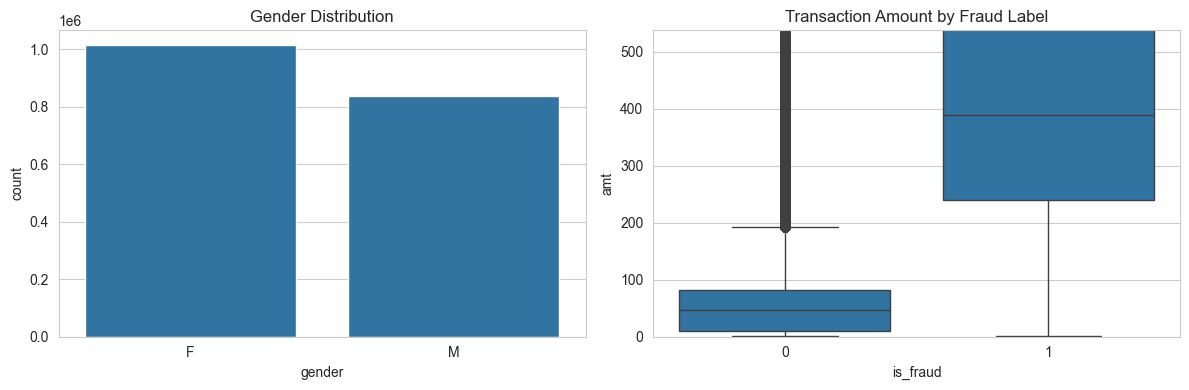

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='gender', data=df_combined, ax=axes[0])
axes[0].set_title('Gender Distribution')
sns.boxplot(x='is_fraud', y='amt', data=df_combined, ax=axes[1])
axes[1].set_title('Transaction Amount by Fraud Label')
axes[1].set_ylim(0, df_combined['amt'].quantile(0.99))
plt.tight_layout()
plt.show()

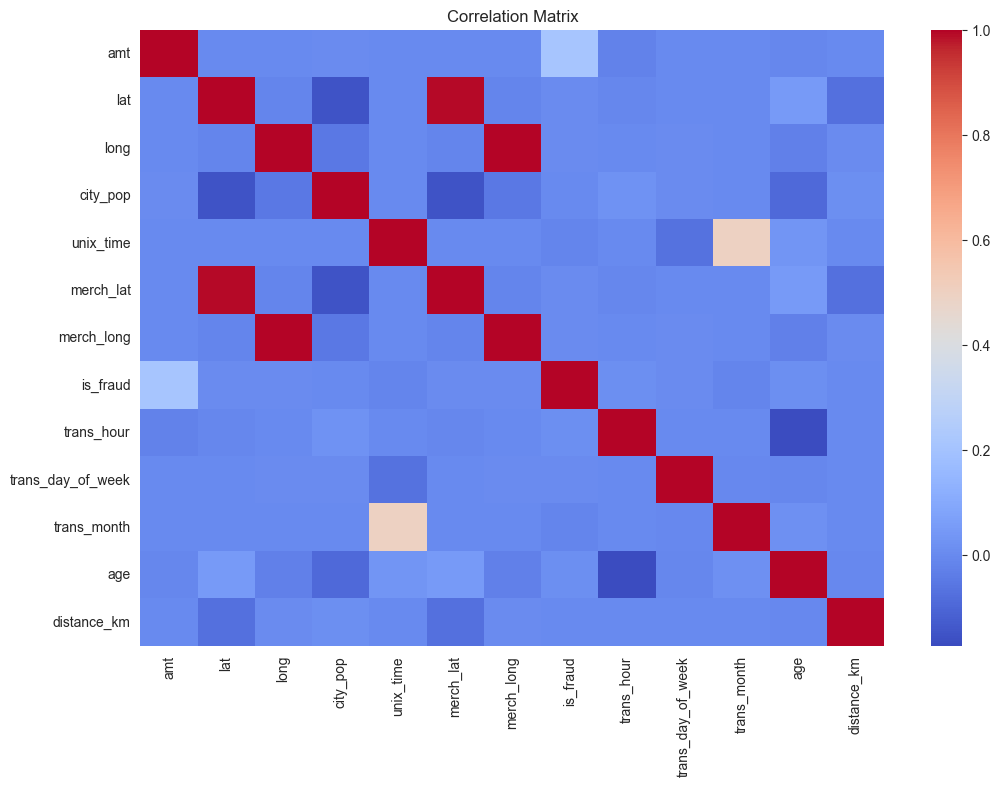

In [12]:
# numeric_only=True: the correlation matrix errors out otherwise, since
# merchant/category/gender are still strings at this point in the pipeline
correlation_matrix = df_combined.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Correlation Matrix')
plt.show()

In [13]:
encoder_merchant = LabelEncoder()
df_combined['merchant_new'] = encoder_merchant.fit_transform(df_combined['merchant'].astype(str))
df_combined.drop(columns=['merchant'], inplace=True)

encoder_category = LabelEncoder()
df_combined['category_new'] = encoder_category.fit_transform(df_combined['category'].astype(str))
df_combined.drop(columns=['category'], inplace=True)

df_combined = pd.get_dummies(df_combined, columns=['gender'], drop_first=True)
df_combined.head()

,amt,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_day_of_week,trans_month,age,distance_km,merchant_new,category_new,gender_M
0,4.97,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0,0,1,1,30,78.597568,514,8,False
1,107.23,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0,0,1,1,40,30.212176,241,4,False
2,220.11,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0,0,1,1,56,108.206083,390,0,True
3,45.00,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0,0,1,1,52,95.673231,360,2,True
4,41.96,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0,0,1,1,32,77.556744,297,9,True


In [15]:
X = df_combined.drop(columns=['is_fraud'])
y = df_combined['is_fraud']

# stratify=y keeps the (small) fraud proportion consistent across the split -
# with a plain random split there's a real risk of under/over-representing
# the minority class in the test set purely by chance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    print(f'--- {name} ---')
    print(confusion_matrix(y_te, preds))
    print(classification_report(y_te, preds, zero_division=0))

    acc = accuracy_score(y_te, preds)
    roc_auc, pr_auc = None, None
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_te)[:, 1]
        roc_auc = roc_auc_score(y_te, proba)
        pr_auc = average_precision_score(y_te, proba)
    print(f'Accuracy: {acc:.4f} | ROC-AUC: {roc_auc} | PR-AUC: {pr_auc}\n')

    results.append({'model': name, 'accuracy': acc, 'roc_auc': roc_auc, 'pr_auc': pr_auc})
    return model

In [18]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_model = evaluate_model('Logistic Regression', lr_model, X_train_scaled, y_train, X_test_scaled, y_test)

--- Logistic Regression ---
[[348066  20483]
 [   446   1484]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97    368549
           1       0.07      0.77      0.12      1930

    accuracy                           0.94    370479
   macro avg       0.53      0.86      0.55    370479
weighted avg       0.99      0.94      0.97    370479

Accuracy: 0.9435 | ROC-AUC: 0.87233349515451 | PR-AUC: 0.1874899759163691



In [19]:
dt_model = DecisionTreeClassifier(class_weight='balanced', random_state=RANDOM_STATE)
dt_model = evaluate_model('Decision Tree', dt_model, X_train, y_train, X_test, y_test)

--- Decision Tree ---
[[368216    333]
 [   370   1560]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.82      0.81      0.82      1930

    accuracy                           1.00    370479
   macro avg       0.91      0.90      0.91    370479
weighted avg       1.00      1.00      1.00    370479

Accuracy: 0.9981 | ROC-AUC: 0.9036933060426285 | PR-AUC: 0.6671015293122019



In [20]:
rf_model = RandomForestClassifier(
    n_estimators=100, n_jobs=-1, class_weight='balanced', random_state=RANDOM_STATE
)
rf_model = evaluate_model('Random Forest', rf_model, X_train, y_train, X_test, y_test)

--- Random Forest ---
[[368519     30]
 [   527   1403]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    368549
           1       0.98      0.73      0.83      1930

    accuracy                           1.00    370479
   macro avg       0.99      0.86      0.92    370479
weighted avg       1.00      1.00      1.00    370479

Accuracy: 0.9985 | ROC-AUC: 0.9900067484927624 | PR-AUC: 0.9175438576892291



,accuracy,roc_auc,pr_auc
model,,,
Logistic Regression,0.943508,0.872333,0.187490
Decision Tree,0.998102,0.903693,0.667102
Random Forest,0.998497,0.990007,0.917544


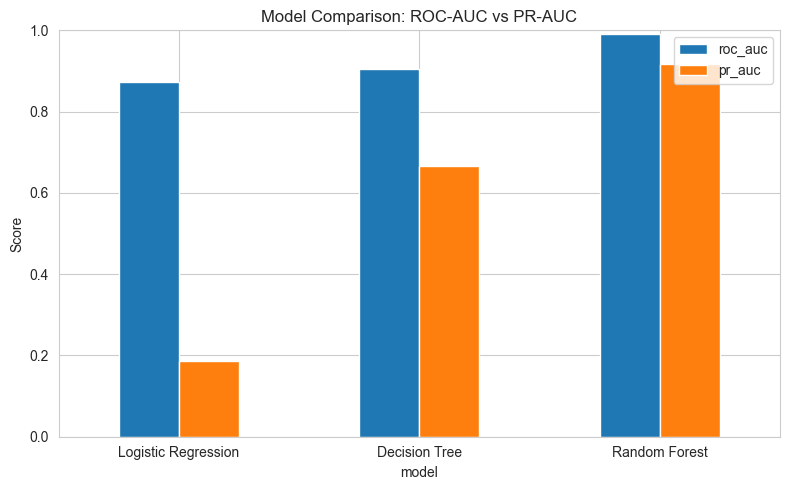

In [21]:
results_df = pd.DataFrame(results).set_index('model')
display(results_df)

results_df[['roc_auc', 'pr_auc']].plot(kind='bar', figsize=(8, 5))
plt.title('Model Comparison: ROC-AUC vs PR-AUC')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

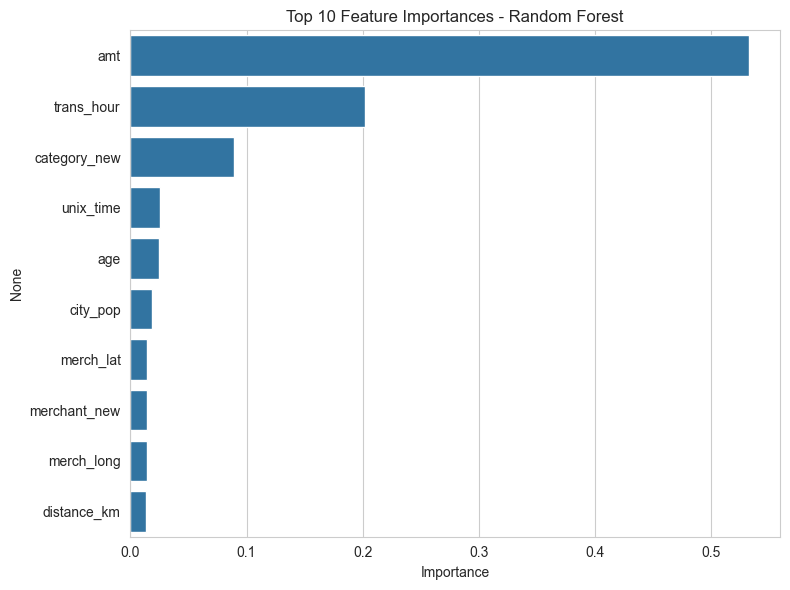

In [22]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()